<a href="https://colab.research.google.com/github/nhasibuan/dicoding-submission/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Your_Name(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Penting**
- Jangan menambahkan import libary atau function apa pun, selain yang sudah tersedia pada cell code.
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Ingat, tugas Anda hanyalah melengkapi code yang rumpang pada bagian yang sudah ditandai "________" saja.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset transaksi keuangan dengan **2.512 sampel** untuk eksplorasi deteksi penipuan dan identifikasi anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Semua library yang dibutuhkan harus **import** di **cell** ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **2. Memuat Dataset**
Loading dataset, tampilkan head, info, dan describe.

In [2]:
# Load data

### MULAI CODE ###

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

### SELESAI CODE ###

In [3]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()

### SELESAI CODE ###

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

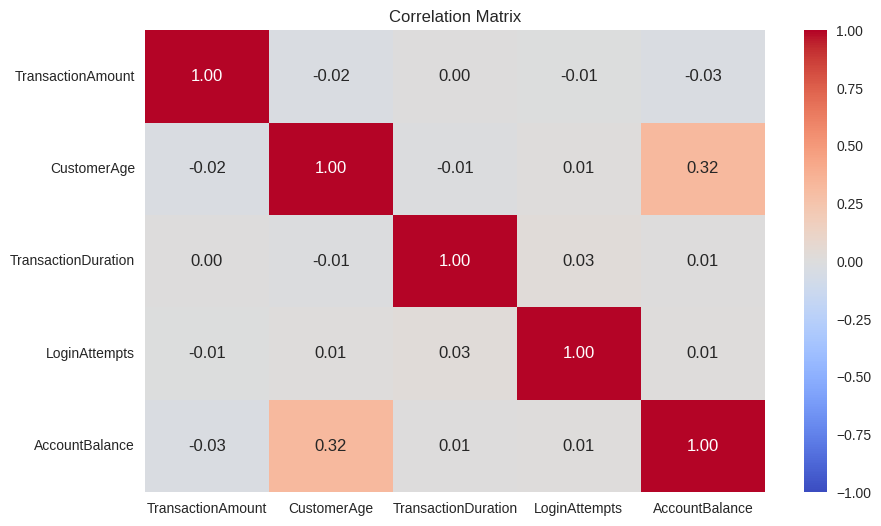

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1,
            vmax=1)
plt.title('Correlation Matrix')
plt.show()

### SELESAI CODE ###

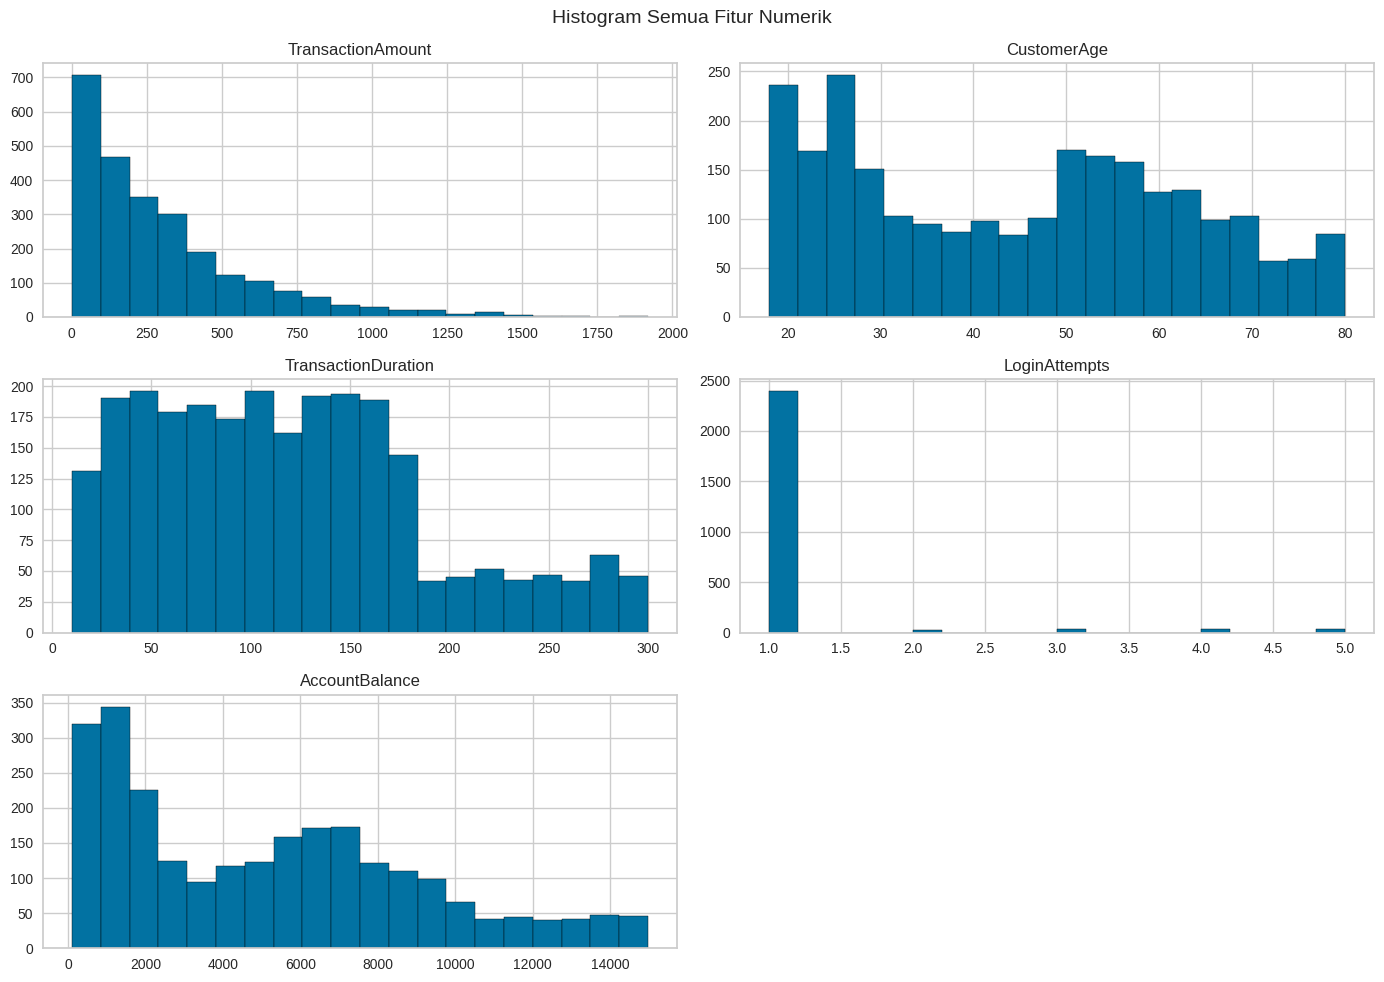

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

### MULAI CODE ###

df[numerical_cols].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Histogram Semua Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

### SELESAI CODE ###

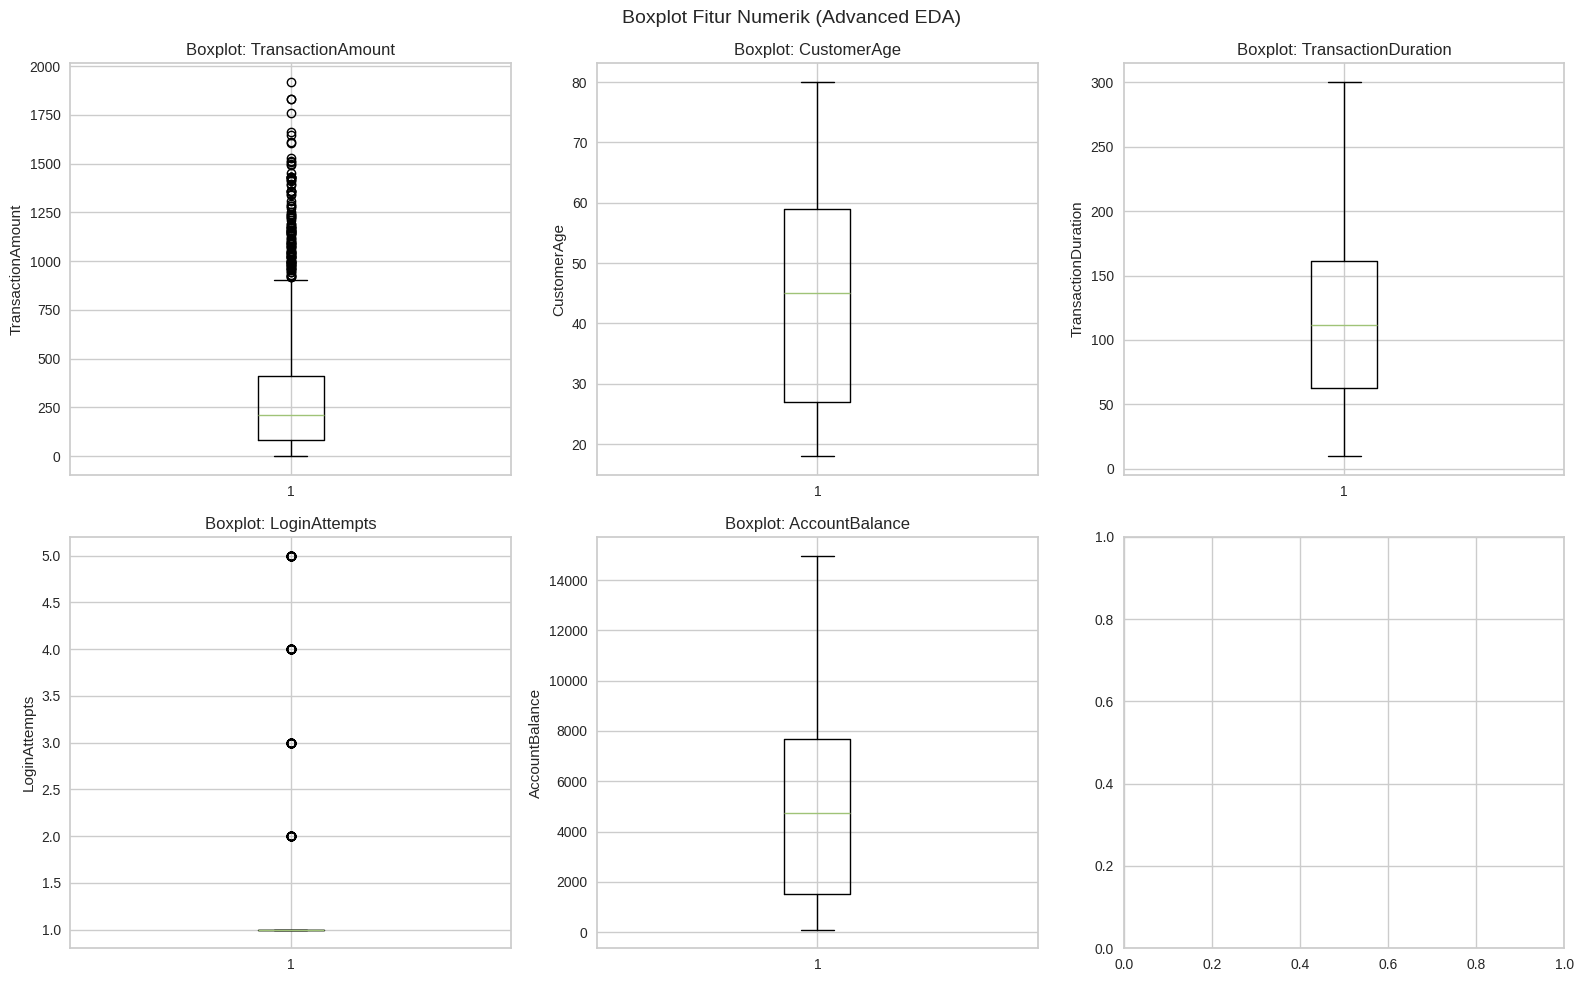

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

### MULAI CODE ###

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:6]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplot Fitur Numerik (Advanced EDA)', fontsize=14)
plt.tight_layout()
plt.show()

### SELESAI CODE ###

# **3. Pembersihan dan Pra Pemrosesan Data**

1. Mengecek dataset menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan drop pada data null/nan dan data yang duplicate.
3. Melakukan drop pada seluruh kolom id, address, dan date.
4. Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.


In [9]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()

### SELESAI CODE ###

np.int64(21)

In [11]:
# Menangani data yang hilang.

### MULAI CODE ###

df = df.dropna()
df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [12]:
# Menghapus data duplikat.

### MULAI CODE ###

df = df.drop_duplicates()
df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [13]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

### MULAI CODE ###

cols_to_drop = [col for col in df.columns
                if any(k in col.lower() for k in ['id', 'address', 'date'])]
df = df.drop(columns=cols_to_drop)
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.

### MULAI CODE ###

le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Simpan mapping untuk inverse transform nanti
le_mapping = {}
for col in categorical_cols:
    le.fit(df[col])
    le_mapping[col] = dict(zip(le.transform(le.classes_), le.classes_))
    df[col] = le.transform(df[col])

df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.

### MULAI CODE ###

df.columns.tolist()

### SELESAI CODE ###

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [16]:
# Melakukan Handling Outlier Data menggunakan metode drop.

### MULAI CODE ###

num_cols = df.select_dtypes(include=['number']).columns.tolist()
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask].reset_index(drop=True)

print(f'Shape setelah drop outlier: {df.shape}')
df.head()

### SELESAI CODE ###

Shape setelah drop outlier: (1501, 9)


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
4,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [17]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.

### MULAI CODE ###

scaler = StandardScaler()
df_scaled = df.copy()
num_cols = df.select_dtypes(include=['number']).columns.tolist()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
df_scaled.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.107930,0.0,1.200869,-1.088615,1.444427,-1.316889,-0.537894,0.0,0.014221
1,0.579431,0.0,-0.503358,-1.088615,1.331694,-1.316889,0.304662,0.0,2.253155
2,-0.585158,0.0,0.145871,1.361177,-1.430270,1.311635,-0.888959,0.0,-1.018894
3,-0.313941,0.0,0.957408,1.361177,-1.035703,1.311635,-1.324280,0.0,0.909321
4,-0.744226,0.0,0.551640,-1.088615,-1.486636,1.311635,0.739983,0.0,-1.107106


In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik.

### MULAI CODE ###

# Binning TransactionAmount menjadi 3 kategori
amount_bins = [df['TransactionAmount'].min() - 1,
               df['TransactionAmount'].quantile(0.33),
               df['TransactionAmount'].quantile(0.66),
               df['TransactionAmount'].max() + 1]
df_scaled['TransactionAmount_bin'] = pd.cut(
    df['TransactionAmount'],
    bins=amount_bins,
    labels=[0, 1, 2]
).astype(int)

print('Distribusi TransactionAmount_bin:')
print(df_scaled['TransactionAmount_bin'].value_counts().sort_index())
df_scaled.head()

### SELESAI CODE ###

Distribusi TransactionAmount_bin:
TransactionAmount_bin
0    496
1    495
2    510
Name: count, dtype: int64


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_bin
0,-1.107930,0.0,1.200869,-1.088615,1.444427,-1.316889,-0.537894,0.0,0.014221,0
1,0.579431,0.0,-0.503358,-1.088615,1.331694,-1.316889,0.304662,0.0,2.253155,2
2,-0.585158,0.0,0.145871,1.361177,-1.430270,1.311635,-0.888959,0.0,-1.018894,1
3,-0.313941,0.0,0.957408,1.361177,-1.035703,1.311635,-1.324280,0.0,0.909321,1
4,-0.744226,0.0,0.551640,-1.088615,-1.486636,1.311635,0.739983,0.0,-1.107106,0


In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing

### MULAI CODE ###

df_scaled.describe()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_bin
count,1.501000e+03,1501.0,1.501000e+03,1501.000000,1.501000e+03,1.501000e+03,1.501000e+03,1501.0,1.501000e+03,1501.000000
mean,-4.733796e-17,0.0,-8.520832e-17,0.000000,4.733796e-18,-5.798900e-17,-1.183449e-18,0.0,2.781105e-16,1.009327
std,1.000333e+00,0.0,1.000333e+00,1.000333,1.000333e+00,1.000333e+00,1.000333e+00,0.0,1.000333e+00,0.818889
min,-1.172368e+00,0.0,-1.720664e+00,-1.088615,-1.486636e+00,-1.316889e+00,-1.534919e+00,0.0,-1.283047e+00,0.000000
25%,-8.072665e-01,0.0,-9.091267e-01,-1.088615,-9.793367e-01,-1.316889e+00,-7.906613e-01,0.0,-9.337901e-01,0.000000
50%,-2.725665e-01,0.0,-1.643619e-02,0.136281,-2.110461e-02,-4.407141e-01,-1.025737e-01,0.0,-1.034678e-01,1.000000
75%,5.277131e-01,0.0,8.762543e-01,1.361177,8.243943e-01,1.311635e+00,6.135991e-01,0.0,6.647565e-01,2.000000
max,3.034644e+00,0.0,1.687791e+00,1.361177,2.008093e+00,1.311635e+00,2.537436e+00,0.0,2.568818e+00,2.000000


# **4. Pengembangan Model Clustering**

1. Elbow Method dengan KElbowVisualizer.
2. KMeans dengan k optimal.
3. Simpan model.
4. Silhouette Score.
5. Visualisasi clustering.
6. PCA model.


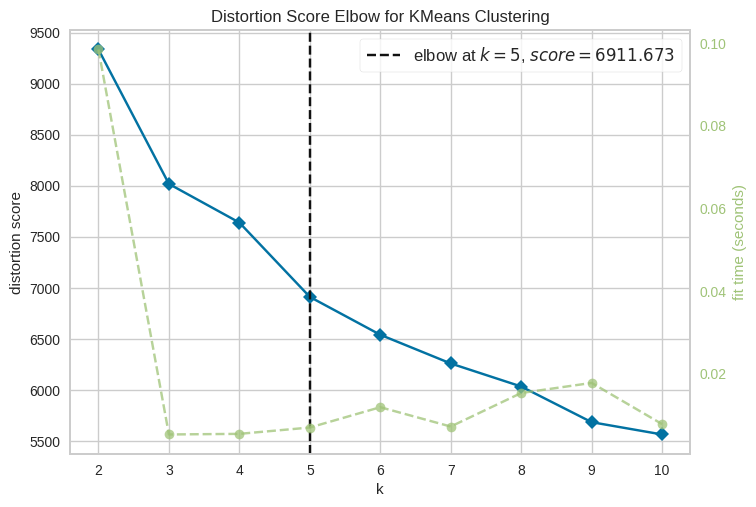

Jumlah cluster optimal: 5


In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

### MULAI CODE ###

X_cluster = df_scaled.values

model_elbow = KMeans(random_state=42)
visualizer = KElbowVisualizer(model_elbow, k=(2, 11))
visualizer.fit(X_cluster)
visualizer.show()

optimal_k = visualizer.elbow_value_
print(f'Jumlah cluster optimal: {optimal_k}')

### SELESAI CODE ###

In [21]:
# Menggunakan algoritma K-Means Clustering

### MULAI CODE ###

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_cluster)
df_scaled['Cluster'] = kmeans.labels_
df['Cluster'] = kmeans.labels_

print(f'Distribusi Cluster:')
print(df['Cluster'].value_counts().sort_index())

### SELESAI CODE ###

Distribusi Cluster:
Cluster
0    281
1    322
2    373
3    391
4    134
Name: count, dtype: int64


In [22]:
# Menyimpan model menggunakan joblib

### MULAI CODE ###

joblib.dump(kmeans, 'model_clustering.h5')
print('Model clustering tersimpan sebagai model_clustering.h5')

### SELESAI CODE ###

Model clustering tersimpan sebagai model_clustering.h5


In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.

### MULAI CODE ###

sil_score = silhouette_score(X_cluster, kmeans.labels_)
print(f'Silhouette Score (k={optimal_k}): {sil_score:.4f}')

### SELESAI CODE ###

Silhouette Score (k=5): 0.1560


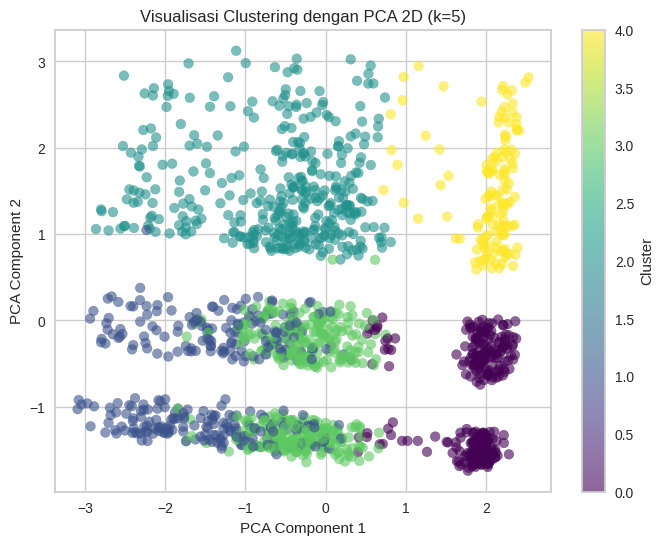

In [24]:
# Membuat visualisasi hasil clustering

### MULAI CODE ###

pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                      c=kmeans.labels_, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Visualisasi Clustering dengan PCA 2D (k={optimal_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

### SELESAI CODE ###

In [25]:
# Membangun model menggunakan PCA.

### MULAI CODE ###

pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_cluster)

print(f'Explained variance ratio: {pca_model.explained_variance_ratio_}')
print(f'Total variance explained: {pca_model.explained_variance_ratio_.sum():.4f}')

### SELESAI CODE ###

Explained variance ratio: [0.25503139 0.2032028 ]
Total variance explained: 0.4582


In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini

joblib.dump(pca_model, 'PCA_model_clustering.h5')
print('Model PCA tersimpan sebagai PCA_model_clustering.h5')

Model PCA tersimpan sebagai PCA_model_clustering.h5


# **5. Analisis dan Interpretasi Cluster**

Analisis deskriptif dan inverse transform dataset.

In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.

### MULAI CODE ###

num_cols_orig = df.select_dtypes(include=['number']).columns.drop('Cluster').tolist()

desc_stats = df.groupby('Cluster')[num_cols_orig].agg(['mean', 'min', 'max'])
print('Analisis Deskriptif per Cluster (data encoded):')
desc_stats

### SELESAI CODE ###

Analisis Deskriptif per Cluster (data encoded):


TransactionAmount                 TransactionType           Location  \
                     mean     min     max            mean min max       mean   
Cluster                                                                        
0              129.703452    0.26  295.64             1.0   1   1  20.793594   
1              116.209876    0.32  317.12             1.0   1   1  22.363354   
2              490.313485  297.15  896.79             1.0   1   1  21.337802   
3              125.329207    0.84  305.92             1.0   1   1  20.240409   
4              539.659328  299.92  903.19             1.0   1   1  21.701493   

                  Channel  ... CustomerOccupation TransactionDuration        \
        min max      mean  ...                max                mean   min   
Cluster                    ...                                                
0         0  42  0.946619  ...                  3          118.747331  13.0   
1         0  42  0.857143  ...                  1          122.760870  10.0   
2         0  42  0.892761  ...                  2          118.396783  10.0   
3         0  42  0.877238  ...                  2          115.306905  11.0   
4         0  42  0.865672  ...                  3          126.358209  11.0   

               LoginAttempts           AccountBalance                     
           max          mean  min  max           mean      min       max  
Cluster                                                                   
0        299.0           1.0  1.0  1.0    1554.393772   123.24   9716.68  
1        300.0           1.0  1.0  1.0    9225.031553  1319.85  14942.78  
2        296.0           1.0  1.0  1.0    6476.985871   135.96  14977.99  
3        296.0           1.0  1.0  1.0    3990.806215   112.76   8092.94  
4        291.0           1.0  1.0  1.0    1547.956642   102.20   9532.42  

[5 rows x 27 columns]

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target

### MULAI CODE ###

df = df.rename(columns={'Cluster': 'Target'})
print('Kolom setelah rename:')
print(df.columns.tolist())
print('\nDistribusi Target:')
print(df['Target'].value_counts().sort_index())

### SELESAI CODE ###

Kolom setelah rename:
['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'Target']

Distribusi Target:
Target
0    281
1    322
2    373
3    391
4    134
Name: count, dtype: int64


In [29]:
# Simpan Data

### MULAI CODE ###

df.to_csv('data_clustering.csv', index=False)
print(f'data_clustering.csv tersimpan: {df.shape[0]} baris, {df.shape[1]} kolom')

### SELESAI CODE ###

data_clustering.csv tersimpan: 1501 baris, 10 kolom


In [30]:
# inverse dataset ke rentang normal untuk numerikal

### MULAI CODE ###

df_inverse = df.copy()

# Drop kolom binning sebelum inverse numerik
bin_cols = [c for c in df_inverse.columns if '_bin' in c]
df_inverse = df_inverse.drop(columns=bin_cols)

# Kolom numerik yang di-scale (exclude Target)
num_cols_to_inv = [c for c in num_cols if c in df_inverse.columns]
df_inverse[num_cols_to_inv] = scaler.inverse_transform(
    df_inverse[num_cols_to_inv]
)

print('Inverse numerik selesai.')
df_inverse.head()

### SELESAI CODE ###

Inverse numerik selesai.


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,3275.945995,2.0,464.805308,0.888741,1286.244697,1.502998,5887.465587,2.0,1.974826e+07,3
1,81002.393988,2.0,206.037022,0.888741,1250.762689,1.502998,10160.177531,2.0,5.314156e+07,2
2,27356.872310,2.0,304.615416,2.521532,381.453493,4.926973,4107.168944,2.0,4.339540e+06,0
3,39850.194242,2.0,427.838410,2.521532,505.640521,4.926973,1899.601107,2.0,3.309852e+07,0
4,20029.574410,2.0,366.226913,0.888741,363.712489,4.926973,12367.745369,2.0,3.023882e+06,0


In [31]:
# inverse dataset yang sudah diencode ke kategori aslinya.

### MULAI CODE ###

for col, mapping in le_mapping.items():
    if col in df_inverse.columns:
        df_inverse[col] = df_inverse[col].map(mapping)

print('Inverse encoding selesai.')
df_inverse.head()

### SELESAI CODE ###

Inverse encoding selesai.


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,3275.945995,NaN,NaN,NaN,1286.244697,NaN,5887.465587,2.0,1.974826e+07,3
1,81002.393988,NaN,NaN,NaN,1250.762689,NaN,10160.177531,2.0,5.314156e+07,2
2,27356.872310,NaN,NaN,NaN,381.453493,NaN,4107.168944,2.0,4.339540e+06,0
3,39850.194242,NaN,NaN,NaN,505.640521,NaN,1899.601107,2.0,3.309852e+07,0
4,20029.574410,NaN,NaN,NaN,363.712489,NaN,12367.745369,2.0,3.023882e+06,0


In [32]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik
# dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.

### MULAI CODE ###

num_inv = df_inverse.select_dtypes(include=['number']).columns.drop('Target').tolist()
cat_inv = df_inverse.select_dtypes(include=['object']).columns.tolist()

print('=== Statistik Numerik per Cluster (data inverse) ===')
print(df_inverse.groupby('Target')[num_inv].agg(['mean', 'min', 'max']))

print('\n=== Mode Kategorikal per Cluster (data inverse) ===')
for col in cat_inv:
    print(f'\n{col}:')
    print(df_inverse.groupby('Target')[col].agg(lambda x: x.mode().iloc[0]))

### SELESAI CODE ###

=== Statistik Numerik per Cluster (data inverse) ===
       TransactionAmount                               CustomerAge  \
                    mean           min            max         mean   
Target                                                               
0           28089.484476    307.682083   63703.618044   458.604763   
1           25193.425530    320.559584   68313.763296   844.207197   
2          105485.417097  64027.701812  192725.443837   965.622424   
3           27150.662136    432.164590   65909.963164  1089.732451   
4          116076.269252  64622.213094  194099.043912   457.448540   

                                TransactionDuration               \
               min          max                mean          min   
Target                                                             
0       363.712489   594.345541         8575.523451  1045.058718   
1       505.640521  1286.244697         8861.335024   831.423121   
2       505.640521  1463.654737         8550.5

IndexError: single positional indexer is out-of-bounds

In [ ]:
# Periksa kembali data yang telah di-inverse.

### MULAI CODE ###

print('Shape:', df_inverse.shape)
print('\nInfo:')
df_inverse.info()
df_inverse.head()

### SELESAI CODE ###

In [ ]:
# Simpan Data Inverse

### MULAI CODE ###

df_inverse.to_csv('data_clustering_inverse.csv', index=False)
print(f'data_clustering_inverse.csv tersimpan: {df_inverse.shape[0]} baris, {df_inverse.shape[1]} kolom')

### SELESAI CODE ###

End of Code